Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6725 - loss: 1.0121
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8281 - loss: 0.4527
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8687 - loss: 0.3466
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8938 - loss: 0.3114
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9187 - loss: 0.2553
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9206 - loss: 0.2209
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9269 - loss: 0.2073
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9431 - loss: 0.1674
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9500 - loss: 0.1488
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9550 - loss: 0.1292


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,390 (677.31 KB)

 Trainable params: 57,796 (225.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 115,594 (451.54 KB)

None
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9275 - loss: 0.2117  
Loss:  0.21165123581886292
Accuracy:  0.9275000095367432


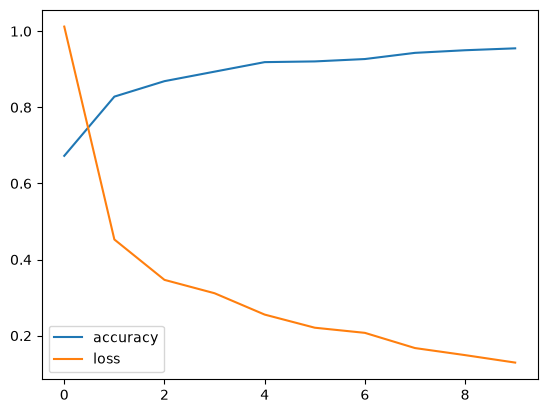

In [2]:

import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, MaxPooling2D, Flatten, Conv2D
from keras.utils import to_categorical


csv_path = r'C:\My Files\ANN & ML Projects\ANNDL_Fall_2026\Project_ANNDL_Fall_2026\data\processed\Images28.csv'
data = pd.read_csv(csv_path, header=None)

Y = data.iloc[:, 0].values
X = data.iloc[:, 1:].values
X = X.reshape(-1, 28, 28, 3)
X = X.astype('float32') / 255.0

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=42)

num_classes = 4
Ytrain = to_categorical(Ytrain, num_classes)
Ytest = to_categorical(Ytest, num_classes)

cnn = Sequential()
cnn.add(Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 3)))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Conv2D(filters=64, kernel_size=(5, 5), activation='relu', padding='valid', strides=(1, 1)))
cnn.add(MaxPooling2D(2, 2))
cnn.add(Flatten())
cnn.add(Dense(4, activation='softmax'))

cnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

result = cnn.fit(Xtrain, Ytrain, epochs=10, batch_size=100, verbose=1)
print(cnn.summary())
loss,acc = cnn.evaluate(Xtest,Ytest)
print("Loss: ", loss)
print("Accuracy: ",acc)
pd.DataFrame(result.history).plot()
plt.show()
cnn.save('C:\\My Files\\ANN & ML Projects\\ANNDL_Fall_2026\\Project_ANNDL_Fall_2026\\models\\images28_cnn_model.keras')



In [6]:
model1 = tf.keras.models.load_model(r"C:\My Files\ANN & ML Projects\ANNDL_Fall_2026\Project_ANNDL_Fall_2026\models\images28_cnn_model.keras")
image = cv2.imread(r"C:\My Files\ANN & ML Projects\ANNDL_Fall_2026\Project_ANNDL_Fall_2026\data\sample\sneaker.jpeg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image1 = cv2.resize(image, (28, 28))
image1 = image1.astype("float32") / 255.0
test_img = image1.reshape(1, 28, 28, 3)
#test_img = np.expand_dims(test_img, axis=0)
p = model1.predict(test_img)
labels = {0: "Boot", 1: "Sandal", 2: "Shoe", 3: "Sneaker"}
ind = np.argmax(p)
print(labels[ind])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Sandal


Epoch 1/10


c:\Users\raoaf\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5956 - loss: 1.0720
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8000 - loss: 0.5376
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8087 - loss: 0.4750
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8325 - loss: 0.4247
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8719 - loss: 0.3676
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8775 - loss: 0.3301
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8919 - loss: 0.2994
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9062 - loss: 0.2821
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9013 - loss: 0.2661
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9119 - loss: 0.2532


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,390 (677.31 KB)

 Trainable params: 57,796 (225.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 115,594 (451.54 KB)

None
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9125 - loss: 0.2368  
Loss:  0.23678505420684814
Accuracy:  0.9125000238418579


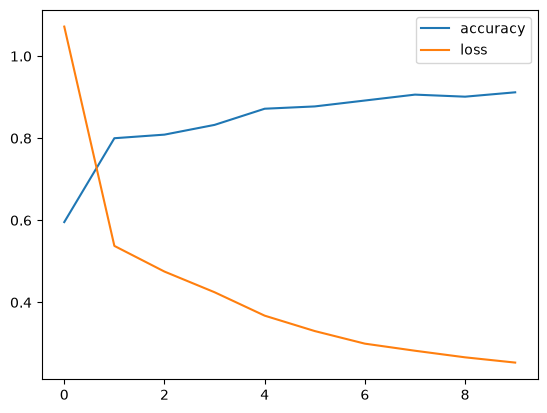

In [7]:

import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, AveragePooling2D, Flatten, Conv2D
from keras.utils import to_categorical


csv_path = r'C:\My Files\ANN & ML Projects\ANNDL_Fall_2026\Project_ANNDL_Fall_2026\data\processed\Images28.csv'
data = pd.read_csv(csv_path, header=None)

Y = data.iloc[:, 0].values
X = data.iloc[:, 1:].values
X = X.reshape(-1, 28, 28, 3)
X = X.astype('float32') / 255.0

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=42)

num_classes = 4
Ytrain = to_categorical(Ytrain, num_classes)
Ytest = to_categorical(Ytest, num_classes)

cnn = Sequential()
cnn.add(Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 3)))
cnn.add(AveragePooling2D(pool_size=(2, 2)))
cnn.add(Conv2D(filters=64, kernel_size=(5, 5), activation='relu', padding='valid', strides=(1, 1)))
cnn.add(AveragePooling2D(2, 2))
cnn.add(Flatten())
cnn.add(Dense(4, activation='softmax'))

cnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

result = cnn.fit(Xtrain, Ytrain, epochs=10, batch_size=100, verbose=1)
print(cnn.summary())
loss,acc = cnn.evaluate(Xtest,Ytest)
print("Loss: ", loss)
print("Accuracy: ",acc)
pd.DataFrame(result.history).plot()
plt.show()
cnn.save('C:\\My Files\\ANN & ML Projects\\ANNDL_Fall_2026\\Project_ANNDL_Fall_2026\\models\\images28_avg_cnn_model.keras')



In [8]:
model1 = tf.keras.models.load_model(r"C:\My Files\ANN & ML Projects\ANNDL_Fall_2026\Project_ANNDL_Fall_2026\models\images28_avg_cnn_model.keras")
image = cv2.imread(r"C:\My Files\ANN & ML Projects\ANNDL_Fall_2026\Project_ANNDL_Fall_2026\data\sample\sneaker.jpeg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image1 = cv2.resize(image, (28, 28))
image1 = image1.astype("float32") / 255.0
test_img = image1.reshape(1, 28, 28, 3)
#test_img = np.expand_dims(test_img, axis=0)
p = model1.predict(test_img)
labels = {0: "Boot", 1: "Sandal", 2: "Shoe", 3: "Sneaker"}
ind = np.argmax(p)
print(labels[ind])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Sandal
